# VayuVision — AQI Forecast Model Training

## Objective

This notebook trains and evaluates models that predict next-day AQI.

## Models compared

- Naive baseline: predict tomorrow's AQI using today's AQI
- Linear Regression
- Random Forest Regressor

## Evaluation strategy

The data is split chronologically:

- Training: 2015–2018
- Validation: 2019
- Testing: 2020

A chronological split is essential for time-series forecasting because a random split could allow the model to learn from future observations.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

MODEL_DATA_PATH = Path("data/processed/model_ready_data.csv")

if not MODEL_DATA_PATH.exists():
    MODEL_DATA_PATH = Path("../data/processed/model_ready_data.csv")

model_df = pd.read_csv(MODEL_DATA_PATH)
model_df["Date"] = pd.to_datetime(model_df["Date"])

train_df = model_df[
    model_df["Date"].dt.year.between(2015, 2018)
].copy()

validation_df = model_df[
    model_df["Date"].dt.year == 2019
].copy()

test_df = model_df[
    model_df["Date"].dt.year == 2020
].copy()

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Years": ["2015–2018", "2019", "2020"],
    "Rows": [len(train_df), len(validation_df), len(test_df)],
    "Start date": [
        train_df["Date"].min().date(),
        validation_df["Date"].min().date(),
        test_df["Date"].min().date()
    ],
    "End date": [
        train_df["Date"].max().date(),
        validation_df["Date"].max().date(),
        test_df["Date"].max().date()
    ]
})

display(split_summary)

,Dataset,Years,Rows,Start date,End date
0,Training,2015–2018,3001,2015-01-08,2018-12-31
1,Validation,2019,1095,2019-01-01,2019-12-31
2,Testing,2020,546,2020-01-01,2020-06-30


In [3]:
TARGET_COLUMN = "next_day_aqi"


def calculate_metrics(actual, predicted, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "R2": r2_score(actual, predicted)
    }


baseline_predictions = validation_df["AQI"]

baseline_validation_metrics = calculate_metrics(
    actual=validation_df[TARGET_COLUMN],
    predicted=baseline_predictions,
    model_name="Naive Baseline"
)

display(
    pd.DataFrame([baseline_validation_metrics]).round(3)
)

,Model,MAE,RMSE,R2
0,Naive Baseline,20.309,34.098,0.878


In [4]:
numeric_features = [
    "AQI",
    "PM2.5", "PM10", "NO2", "CO", "SO2", "O3",
    "month", "day_of_week", "is_weekend",
    "aqi_lag_1", "aqi_lag_7",
    "aqi_rolling_mean_3", "aqi_rolling_mean_7",
    "pm25_lag_1", "pm10_lag_1",
    "data_quality_score"
]

categorical_features = ["City"]

model_features = numeric_features + categorical_features

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        (
            "city",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    train_df[model_features],
    train_df[TARGET_COLUMN]
)

linear_validation_predictions = linear_model.predict(
    validation_df[model_features]
)

linear_validation_metrics = calculate_metrics(
    actual=validation_df[TARGET_COLUMN],
    predicted=linear_validation_predictions,
    model_name="Linear Regression"
)

display(
    pd.DataFrame(
        [baseline_validation_metrics, linear_validation_metrics]
    ).round(3)
)

,Model,MAE,RMSE,R2
0,Naive Baseline,20.309,34.098,0.878
1,Linear Regression,17.356,27.657,0.920


In [5]:
from sklearn.base import clone

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    train_df[model_features],
    train_df[TARGET_COLUMN]
)

rf_validation_predictions = random_forest_model.predict(
    validation_df[model_features]
)

rf_validation_metrics = calculate_metrics(
    actual=validation_df[TARGET_COLUMN],
    predicted=rf_validation_predictions,
    model_name="Random Forest"
)

validation_comparison = pd.DataFrame(
    [
        baseline_validation_metrics,
        linear_validation_metrics,
        rf_validation_metrics
    ]
).round(3)

display(validation_comparison)

,Model,MAE,RMSE,R2
0,Naive Baseline,20.309,34.098,0.878
1,Linear Regression,17.356,27.657,0.920
2,Random Forest,17.197,27.760,0.919


In [ ]:
development_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
).sort_values("Date")

best_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LinearRegression())
    ]
)

best_model.fit(
    development_df[model_features],
    development_df[TARGET_COLUMN]
)

test_predictions = best_model.predict(
    test_df[model_features]
)

test_metrics = calculate_metrics(
    actual=test_df[TARGET_COLUMN],
    predicted=test_predictions,
    model_name="Linear Regression (Test)"
)

display(
    pd.DataFrame([test_metrics]).round(3)
)

test_results = test_df[
    ["City", "Date", TARGET_COLUMN]
].copy()

test_results["predicted_aqi"] = test_predictions

test_results = test_results.rename(
    columns={TARGET_COLUMN: "actual_aqi"}
)

display(test_results.head())

,Model,MAE,RMSE,R2
0,Linear Regression (Test),14.172,21.042,0.919


,City,Date,actual_aqi,predicted_aqi
1712,Bengaluru,2020-01-01,81.0,82.917324
1713,Bengaluru,2020-01-02,85.0,81.522660
1714,Bengaluru,2020-01-03,95.0,89.076893
1715,Bengaluru,2020-01-04,118.0,110.026768
1716,Bengaluru,2020-01-05,81.0,103.744496


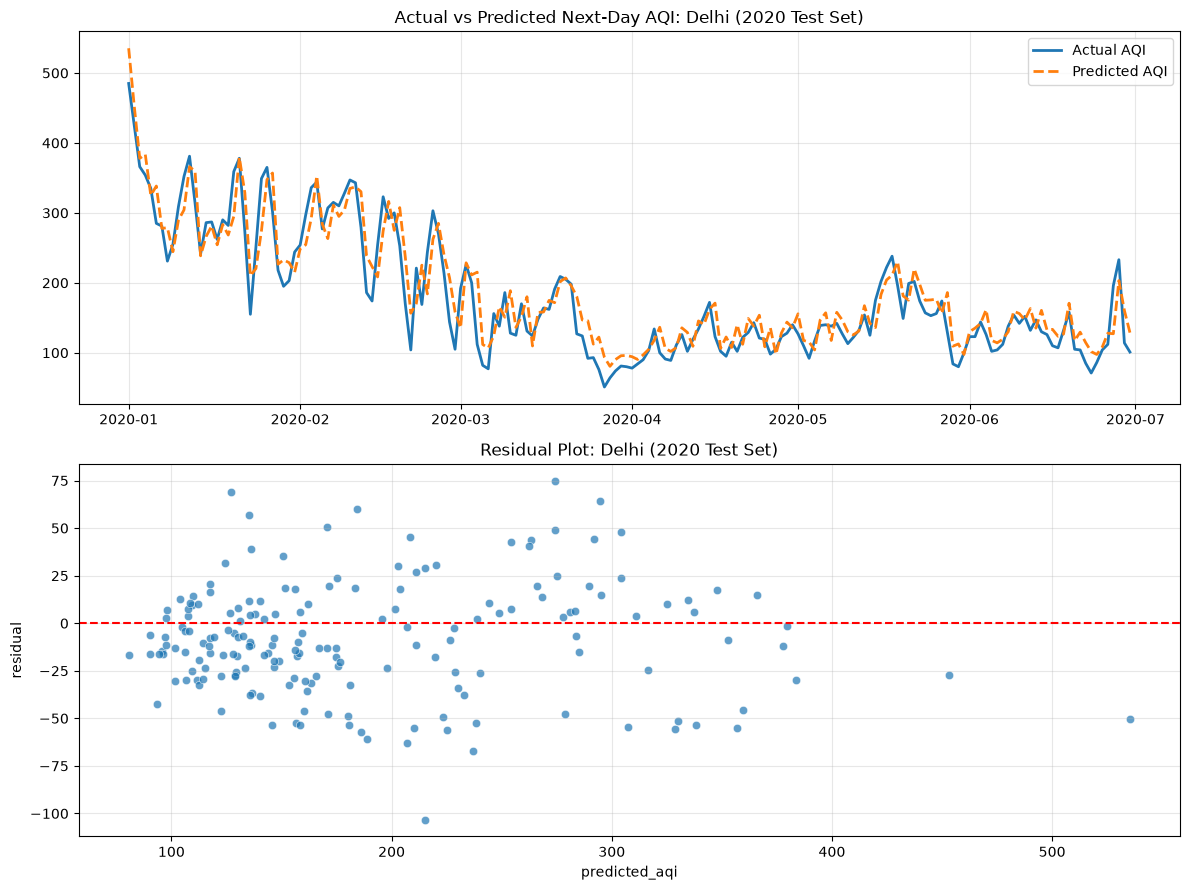

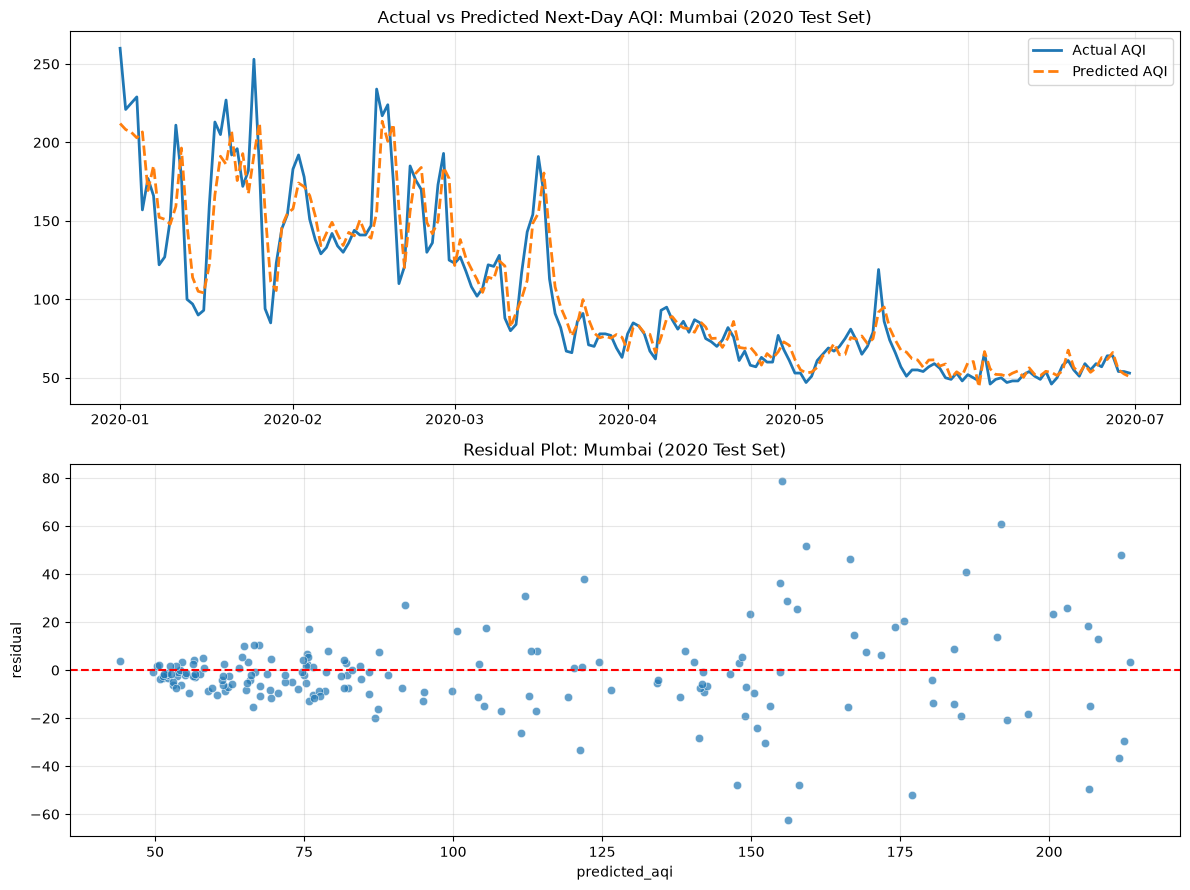

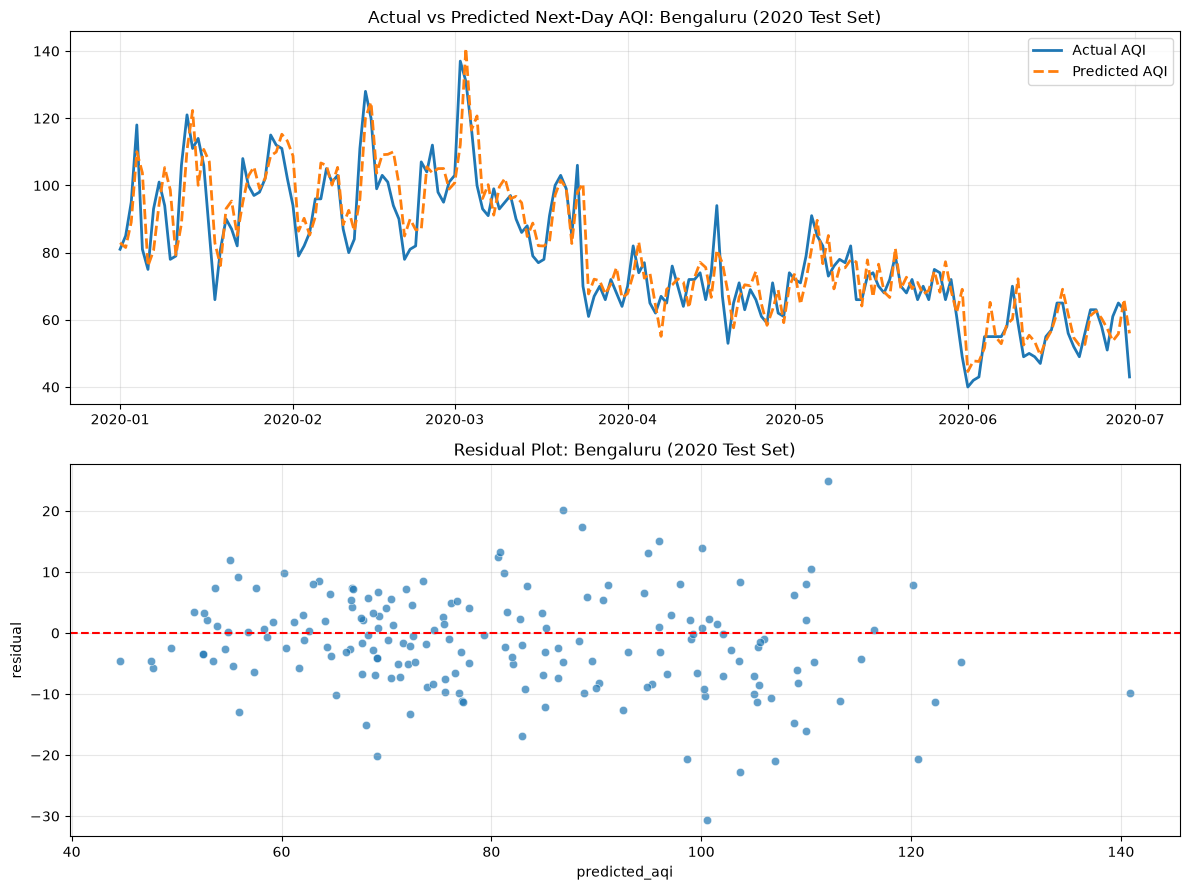

In [8]:
for city in ["Delhi", "Mumbai", "Bengaluru"]:
    city_test_results = (
        test_results[test_results["City"] == city]
        .sort_values("Date")
        .copy()
    )
    city_test_results["residual"] = (
        city_test_results["actual_aqi"] - city_test_results["predicted_aqi"]
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    axes[0].plot(city_test_results["Date"], city_test_results["actual_aqi"], label="Actual AQI", linewidth=2)
    axes[0].plot(city_test_results["Date"], city_test_results["predicted_aqi"], label="Predicted AQI", linewidth=2, linestyle="--")
    axes[0].set_title(f"Actual vs Predicted Next-Day AQI: {city} (2020 Test Set)")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    sns.scatterplot(data=city_test_results, x="predicted_aqi", y="residual", alpha=0.7, ax=axes[1])
    axes[1].axhline(y=0, color="red", linestyle="--")
    axes[1].set_title(f"Residual Plot: {city} (2020 Test Set)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [17]:
import joblib
joblib.dump(best_model, "../models/best_aqi_forecaster.pkl")

final_report = pd.concat([
    pd.DataFrame([test_metrics]),
    per_city_df
], ignore_index=True)
final_report.to_csv("../reports/model_metrics.csv", index=False)